## 0. Load data

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

In [2]:
pfas = pd.read_csv('no_sn_202.csv')
pfas

,Molecule,SMILES,C Count,F Count,Total sp3 Count,sp3 C-F Count,sp3 C-C Count,Total sp2 Count,sp2 C-C Count,Torsions C-C-C-C,...,Torsions H-C-C-C,Torsions H-C-C-O,Torsions H-C-C-H,a0,a1,a2,a3,a4,H_f_0K,S_300K
0,butene,FC(F)=C(F)C(F)(F)C(F)(F)F,4,8,10,8,2,1,1,1,...,0,0,0,8.2447,0.13653,-0.000133,6.050000e-08,-1.040000e-11,-371.81,104.398839
1,butene_OH,OC(F)(F)[C](F)C(F)(F)C(F)(F)F,4,8,13,8,3,0,0,1,...,0,0,0,8.9590,0.16092,-0.000159,7.290000e-08,-1.260000e-11,-419.97,44.901000
2,pentene,FC(F)=C(F)C(F)(F)C(F)(F)C(F)(F)F,5,10,13,10,3,1,1,2,...,0,0,0,10.0620,0.17448,-0.000171,7.770000e-08,-1.330000e-11,-470.07,119.440000
3,hexene,FC(F)=C(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,6,12,16,12,4,1,1,3,...,0,0,0,11.8020,0.21282,-0.000209,9.510000e-08,-1.630000e-11,-567.50,134.200000
4,heptene,FC(F)=C(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,7,14,19,14,5,1,1,4,...,0,0,0,13.3720,0.25169,-0.000248,1.130000e-07,-1.940000e-11,-665.26,147.340000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,pfpeoh,OC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,5,11,17,11,4,0,0,2,...,0,0,0,9.9632,0.21492,-0.000212,9.730000e-08,-1.680000e-11,0.00,127.540000
122,pfpncof,O=C(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F,5,10,14,10,4,1,0,2,...,0,0,0,10.4950,0.18766,-0.000184,8.370000e-08,-1.440000e-11,0.00,123.370000
123,pfpra,O=C(O)C(F)(F)C(F)(F)F,3,5,9,5,2,1,0,0,...,0,0,0,5.7283,0.12156,-0.000117,5.280000e-08,-9.030000e-12,0.00,96.243000
124,pfprcof,O=C(F)C(F)(F)C(F)(F)F,3,6,8,6,2,1,0,0,...,0,0,0,7.0146,0.11110,-0.000108,4.880000e-08,-8.340000e-12,0.00,95.561000


## 1. Data preparation before fitting models

In [3]:
X = pfas[pfas.columns[2:49]]
X

,C Count,F Count,Total sp3 Count,sp3 C-F Count,sp3 C-C Count,Total sp2 Count,sp2 C-C Count,Torsions C-C-C-C,Torsions C-C-C-F,Torsions F-C-C-C,...,Torsions C-O-C-H,Torsions C-O-C-F,Torsions C-O-C-C,Torsions H-C-C-F,Torsions O-C-C-O,Torsions C-O-C-O,Torsions O-C-O-C,Torsions H-C-C-C,Torsions H-C-C-O,Torsions H-C-C-H
0,4,8,10,8,2,1,1,1,5,1,...,0,0,0,0,0,0,0,0,0,0
1,4,8,13,8,3,0,0,1,5,3,...,0,0,0,0,0,0,0,0,0,0
2,5,10,13,10,3,1,1,2,7,3,...,0,0,0,0,0,0,0,0,0,0
3,6,12,16,12,4,1,1,3,8,6,...,0,0,0,0,0,0,0,0,0,0
4,7,14,19,14,5,1,1,4,10,8,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,5,11,17,11,4,0,0,2,9,4,...,0,0,0,0,0,0,0,0,0,0
122,5,10,14,10,4,1,0,2,8,4,...,0,0,0,0,0,0,0,0,0,0
123,3,5,9,5,2,1,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
124,3,6,8,6,2,1,0,0,1,3,...,0,0,0,0,0,0,0,0,0,0


In [4]:
Y = pfas[pfas.columns[49:54]]
Y

,a0,a1,a2,a3,a4
0,8.2447,0.13653,-0.000133,6.050000e-08,-1.040000e-11
1,8.9590,0.16092,-0.000159,7.290000e-08,-1.260000e-11
2,10.0620,0.17448,-0.000171,7.770000e-08,-1.330000e-11
3,11.8020,0.21282,-0.000209,9.510000e-08,-1.630000e-11
4,13.3720,0.25169,-0.000248,1.130000e-07,-1.940000e-11
...,...,...,...,...,...
121,9.9632,0.21492,-0.000212,9.730000e-08,-1.680000e-11
122,10.4950,0.18766,-0.000184,8.370000e-08,-1.440000e-11
123,5.7283,0.12156,-0.000117,5.280000e-08,-9.030000e-12
124,7.0146,0.11110,-0.000108,4.880000e-08,-8.340000e-12


In [5]:
Y1 = pfas[pfas.columns[50:54]]
Y1

,a1,a2,a3,a4
0,0.13653,-0.000133,6.050000e-08,-1.040000e-11
1,0.16092,-0.000159,7.290000e-08,-1.260000e-11
2,0.17448,-0.000171,7.770000e-08,-1.330000e-11
3,0.21282,-0.000209,9.510000e-08,-1.630000e-11
4,0.25169,-0.000248,1.130000e-07,-1.940000e-11
...,...,...,...,...
121,0.21492,-0.000212,9.730000e-08,-1.680000e-11
122,0.18766,-0.000184,8.370000e-08,-1.440000e-11
123,0.12156,-0.000117,5.280000e-08,-9.030000e-12
124,0.11110,-0.000108,4.880000e-08,-8.340000e-12


In [6]:
XY = pd.concat([X,Y], axis = 1)
XY

,C Count,F Count,Total sp3 Count,sp3 C-F Count,sp3 C-C Count,Total sp2 Count,sp2 C-C Count,Torsions C-C-C-C,Torsions C-C-C-F,Torsions F-C-C-C,...,Torsions C-O-C-O,Torsions O-C-O-C,Torsions H-C-C-C,Torsions H-C-C-O,Torsions H-C-C-H,a0,a1,a2,a3,a4
0,4,8,10,8,2,1,1,1,5,1,...,0,0,0,0,0,8.2447,0.13653,-0.000133,6.050000e-08,-1.040000e-11
1,4,8,13,8,3,0,0,1,5,3,...,0,0,0,0,0,8.9590,0.16092,-0.000159,7.290000e-08,-1.260000e-11
2,5,10,13,10,3,1,1,2,7,3,...,0,0,0,0,0,10.0620,0.17448,-0.000171,7.770000e-08,-1.330000e-11
3,6,12,16,12,4,1,1,3,8,6,...,0,0,0,0,0,11.8020,0.21282,-0.000209,9.510000e-08,-1.630000e-11
4,7,14,19,14,5,1,1,4,10,8,...,0,0,0,0,0,13.3720,0.25169,-0.000248,1.130000e-07,-1.940000e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,5,11,17,11,4,0,0,2,9,4,...,0,0,0,0,0,9.9632,0.21492,-0.000212,9.730000e-08,-1.680000e-11
122,5,10,14,10,4,1,0,2,8,4,...,0,0,0,0,0,10.4950,0.18766,-0.000184,8.370000e-08,-1.440000e-11
123,3,5,9,5,2,1,0,0,0,3,...,0,0,0,0,0,5.7283,0.12156,-0.000117,5.280000e-08,-9.030000e-12
124,3,6,8,6,2,1,0,0,1,3,...,0,0,0,0,0,7.0146,0.11110,-0.000108,4.880000e-08,-8.340000e-12


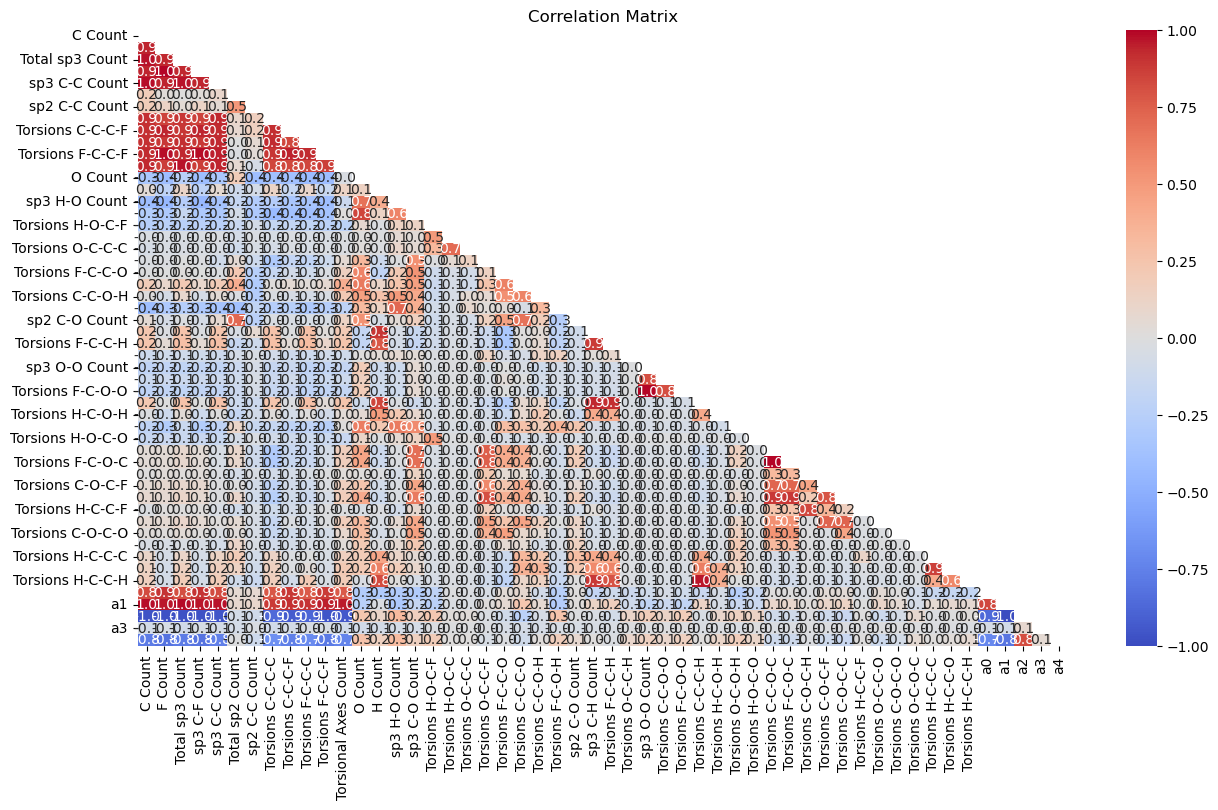

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
XY_corr = XY.corr(method='pearson')
plt.figure(figsize=(15,8))
mask = np.triu(np.ones_like(XY_corr, dtype=bool))
sns.heatmap(XY_corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.1f')
plt.title('Correlation Matrix')
plt.show()

## 2. Fitting models

In [8]:
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, MultiTaskElasticNet, MultiTaskLasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn_evaluation import plot
from sklearn.inspection import permutation_importance

In [9]:
# Fit model and compute regression scores (R2), including CV:
def report_regression_scores(model, X_train, y_train, X_test, y_test, X, y, cv):
    # fit & predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # --- holdout (train/test split) metrics ---
    train_r2   = metrics.r2_score(y_train, y_train_pred)
    test_r2    = metrics.r2_score(y_test, y_pred)
    train_MAE = metrics.mean_absolute_error(y_train, y_train_pred)
    test_MAE = metrics.mean_absolute_error(y_test, y_pred)

    # --- cross-validation metrics ---
    scores = cross_validate(
        model, X, y,
        cv=cv,                    
        return_train_score=True,
        scoring='r2',
    )
    scores_table = pd.DataFrame(scores)

    train_cv_scores = np.round(scores_table["train_score"].values, 3)
    test_cv_scores  = np.round(scores_table["test_score"].values, 3)

    # Build & return a summary table
    summary_df = pd.DataFrame({
        "Train R2":   [round(train_r2,3)],
        "Test R2":    [round(test_r2,3)],
        "Train MAE":    [round(train_MAE,3)],
        "Test MAE":    [round(test_MAE,3)],
        "Train CV Scores": [train_cv_scores],
        "Test CV Scores": [test_cv_scores],
    }, index=[model.__class__.__name__])

    return summary_df

In [10]:
import math
# Plot permutation feature importance
def plot_permutation_importance(models, X_train, y_train, X_test, y_test, feature_names, cols, n_features, n_repeats=30, random_state=15):
    # create subplots
    n = len(models)
    rows = math.ceil(n/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    if n == 1:
        axes = [axes]    
    axes = axes.flatten()

    # fit model and plot permutation feature importance 
    for ax, model in zip(axes, models):
        model.fit(X_train, y_train)
        r = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=random_state)
        idxs = r.importances_mean.argsort()[::-1]

        ax.barh(range(len(idxs)), r.importances_mean[idxs], xerr=r.importances_std[idxs], align='center')
        ax.set_yticks(range(len(idxs)))
        ax.set_yticklabels([feature_names[i] for i in idxs])
        ax.invert_yaxis()
        ax.set_title(f"{model.__class__.__name__}")
        ax.set_xlabel("Permutation Importance")

    for empty_ax in axes[len(models):]:
        empty_ax.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f"PFI_{n_features}features.png",        
            dpi=300,
            bbox_inches='tight')
    plt.show()

In [11]:
# list out all the models I wanna try
models = [LinearRegression(),
          Ridge(alpha=0.5, random_state=42),
          Lasso(alpha=0.01, max_iter=10000, random_state=42),
          MultiTaskLasso(alpha=0.01, max_iter=10000, random_state=42),
          ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42),
          MultiTaskElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42),
          RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1),
          ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1),
          DecisionTreeRegressor(random_state=42),
          KNeighborsRegressor(n_neighbors=3, weights="distance", metric="minkowski", p=1),
          MLPRegressor(
              hidden_layer_sizes=(32,16),
              activation="relu",
              solver="adam",
              alpha=1e-3,
              learning_rate_init=1e-3,
              max_iter=5000,
              early_stopping=True,
              validation_fraction=0.2,
              n_iter_no_change=30,
              random_state=1)]

In [12]:
# Try with data scaled with MinMaxScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler
X_SS = StandardScaler().fit_transform(X)
X_MMS = MinMaxScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_MMS, Y, test_size=0.25, random_state=42)
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MMS, Y, 4)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train MAE,Test MAE,Train CV Scores,Test CV Scores
LinearRegression,8.330000e-01,-1.232302e+14,0.085,0.438,"[0.93, 0.742, 0.83, 0.756]","[0.656, -24010229054419.242, -29777896528813.1..."
Ridge,8.090000e-01,-3.746057e+12,0.119,0.229,"[0.915, 0.722, 0.797, 0.732]","[0.752, -2327879357290.816, -4239442149615.708..."
Lasso,3.290000e-01,-7.462147e+11,0.123,0.237,"[0.333, 0.308, 0.306, 0.329]","[0.28, -570634970582.137, -540910690920.723, -..."
MultiTaskLasso,7.950000e-01,-2.660233e+12,0.123,0.241,"[0.916, 0.705, 0.794, 0.728]","[0.756, -1030366421308.266, -2365538777705.846..."
ElasticNet,3.790000e-01,-1.577928e+12,0.129,0.229,"[0.366, 0.372, 0.359, 0.371]","[0.315, -750122233847.764, -1131671494743.901,..."
MultiTaskElasticNet,8.010000e-01,-2.883378e+12,0.130,0.230,"[0.911, 0.713, 0.789, 0.726]","[0.754, -1322511407854.17, -2753827506160.772,..."
RandomForestRegressor,8.710000e-01,-8.731050e+12,0.115,0.268,"[0.92, 0.808, 0.857, 0.819]","[0.724, -1797723345599.226, -15160079067012.96..."
ExtraTreesRegressor,1.000000e+00,-4.047294e+12,0.002,0.260,"[0.962, 0.95, 1.0, 1.0]","[0.734, -1572433617162.331, -50268465637047.47..."
DecisionTreeRegressor,1.000000e+00,6.050000e-01,0.002,0.246,"[0.962, 0.95, 1.0, 1.0]","[0.686, 0.846, -181917248173384.12, -0.573]"
KNeighborsRegressor,1.000000e+00,-8.784491e+12,0.002,0.247,"[0.962, 0.95, 1.0, 1.0]","[0.606, -3006466668210.408, -6733010670341.976..."
